# Video Game Sales Prediction — Random Forest Regressor

**Dataset:** ~16,600 video games with platform, genre, publisher, year, and regional sales

**Target:** Predict global sales (in millions of units)

**Model choice:** Random Forest Regressor

---

I initially thought linear regression would work here, but when I looked at the data
the global sales column has a skew of 17.4 — meaning a tiny number of games like Wii Sports
(82M units) are so far above the rest that a straight line just can't capture that.

Also, genre, platform, and publisher correlate almost 0 with global sales individually.
The relationships are more like "certain combinations of platform + genre + year do well"
— that's exactly what decision trees pick up on.

Random Forest trains many trees on random subsets of the data, then averages their predictions.
It handles skewed targets and non-linear patterns without needing log transforms or manual tuning.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110


## Load & inspect


In [2]:
df = pd.read_csv('video_games_sales.csv')

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
df.head()


Shape: 16,598 rows x 11 columns

Missing values:
year         271
publisher     58
dtype: int64


,rank,name,platform,year,genre,publisher,na_sales,eu_sales,jp_sales,other_sales,global_sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [3]:
print("Global sales stats:")
print(df['global_sales'].describe().round(3))
print(f"\nSkewness: {df['global_sales'].skew():.2f}")
print("(anything above 1.0 is considered heavily skewed)")


Global sales stats:
count    16598.000
mean         0.537
std          1.555
min          0.010
25%          0.060
50%          0.170
75%          0.470
max         82.740
Name: global_sales, dtype: float64

Skewness: 17.40
(anything above 1.0 is considered heavily skewed)


## Cleaning

Just two things to fix — missing year (fill with median) and missing publisher (fill with 'Unknown').
No log transform needed because Random Forest handles skewed targets fine on its own.


In [4]:
df['year']      = df['year'].fillna(df['year'].median()).astype(int)
df['publisher'] = df['publisher'].fillna('Unknown')

print("Missing values remaining:", df.isnull().sum().sum())


Missing values remaining: 0


## EDA


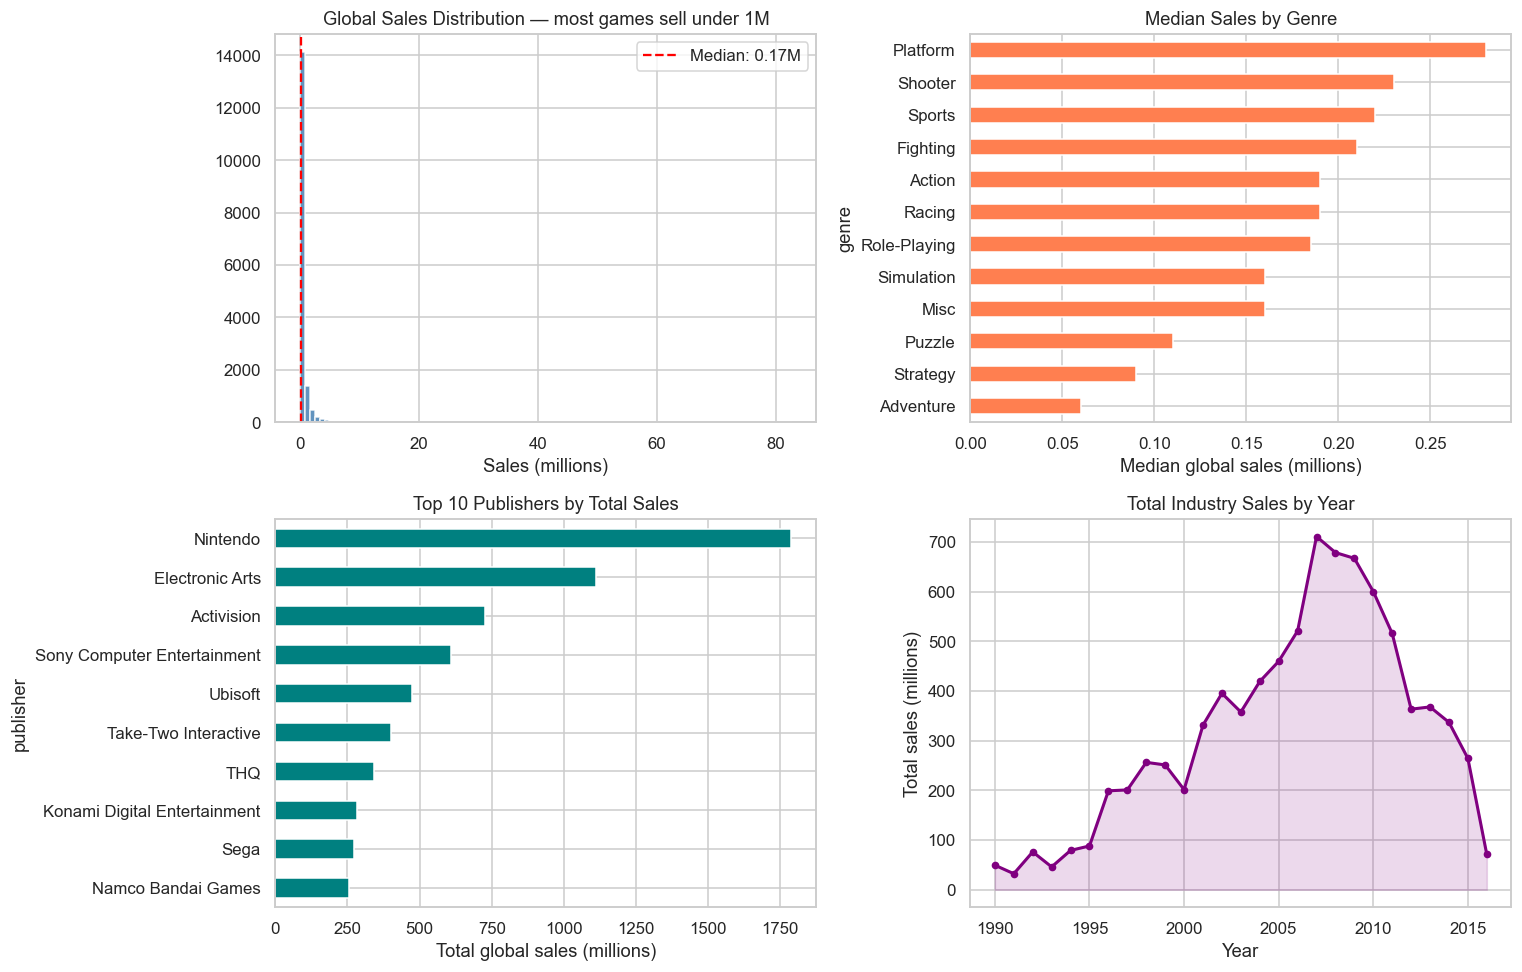

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Sales distribution — heavily right-skewed
axes[0,0].hist(df['global_sales'], bins=100, color='steelblue', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df['global_sales'].median(), color='red', linestyle='--',
                  label=f'Median: {df["global_sales"].median():.2f}M')
axes[0,0].set_title('Global Sales Distribution — most games sell under 1M')
axes[0,0].set_xlabel('Sales (millions)')
axes[0,0].legend()

# Sales by genre
genre_med = df.groupby('genre')['global_sales'].median().sort_values()
genre_med.plot(kind='barh', ax=axes[0,1], color='coral', edgecolor='white')
axes[0,1].set_title('Median Sales by Genre')
axes[0,1].set_xlabel('Median global sales (millions)')

# Top 10 publishers by total sales
top_pub = df.groupby('publisher')['global_sales'].sum().sort_values(ascending=False).head(10)
top_pub.sort_values().plot(kind='barh', ax=axes[1,0], color='teal', edgecolor='white')
axes[1,0].set_title('Top 10 Publishers by Total Sales')
axes[1,0].set_xlabel('Total global sales (millions)')

# Sales trend by year
yearly = df.groupby('year')['global_sales'].sum()
yearly = yearly[(yearly.index >= 1990) & (yearly.index <= 2016)]
axes[1,1].plot(yearly.index, yearly.values, marker='o', color='purple', lw=2, markersize=4)
axes[1,1].fill_between(yearly.index, yearly.values, alpha=0.15, color='purple')
axes[1,1].set_title('Total Industry Sales by Year')
axes[1,1].set_xlabel('Year')
axes[1,1].set_ylabel('Total sales (millions)')

plt.tight_layout()
plt.show()


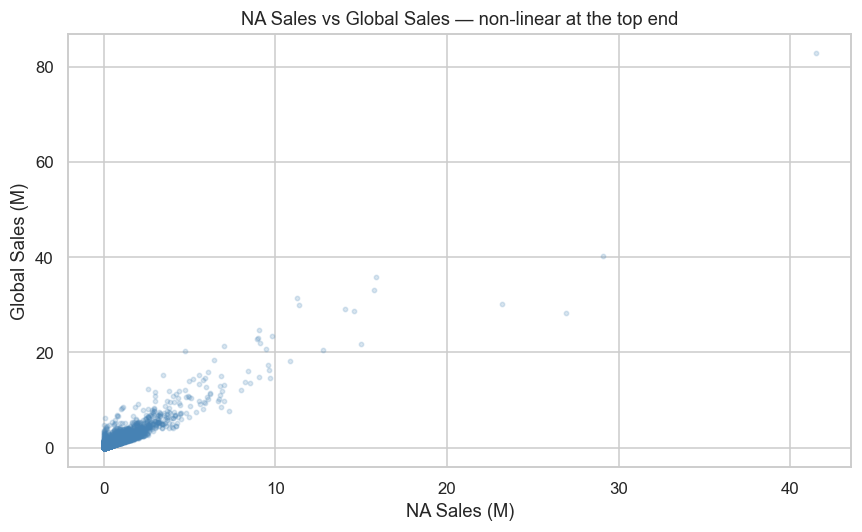

In [6]:
# NA vs global sales — scatter shows the relationship isn't perfectly linear
plt.figure(figsize=(8, 5))
plt.scatter(df['na_sales'], df['global_sales'], alpha=0.2, s=8, color='steelblue')
plt.xlabel('NA Sales (M)')
plt.ylabel('Global Sales (M)')
plt.title('NA Sales vs Global Sales — non-linear at the top end')
plt.tight_layout()
plt.show()


## Features


In [7]:
le = LabelEncoder()
df['platform_enc']  = le.fit_transform(df['platform'])
df['genre_enc']     = le.fit_transform(df['genre'])
df['publisher_enc'] = le.fit_transform(df['publisher'])

features = ['na_sales', 'eu_sales', 'jp_sales', 'other_sales',
            'platform_enc', 'genre_enc', 'publisher_enc', 'year']

X = df[features]
y = df['global_sales']  # raw, no log transform needed

print(f"X: {X.shape}  |  y range: {y.min():.2f} to {y.max():.2f} million")


X: (16598, 8)  |  y range: 0.01 to 82.74 million


## Train & evaluate


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2   = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f} million units")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")


MAE  : 0.0445 million units
RMSE : 0.9039
R2   : 0.8055


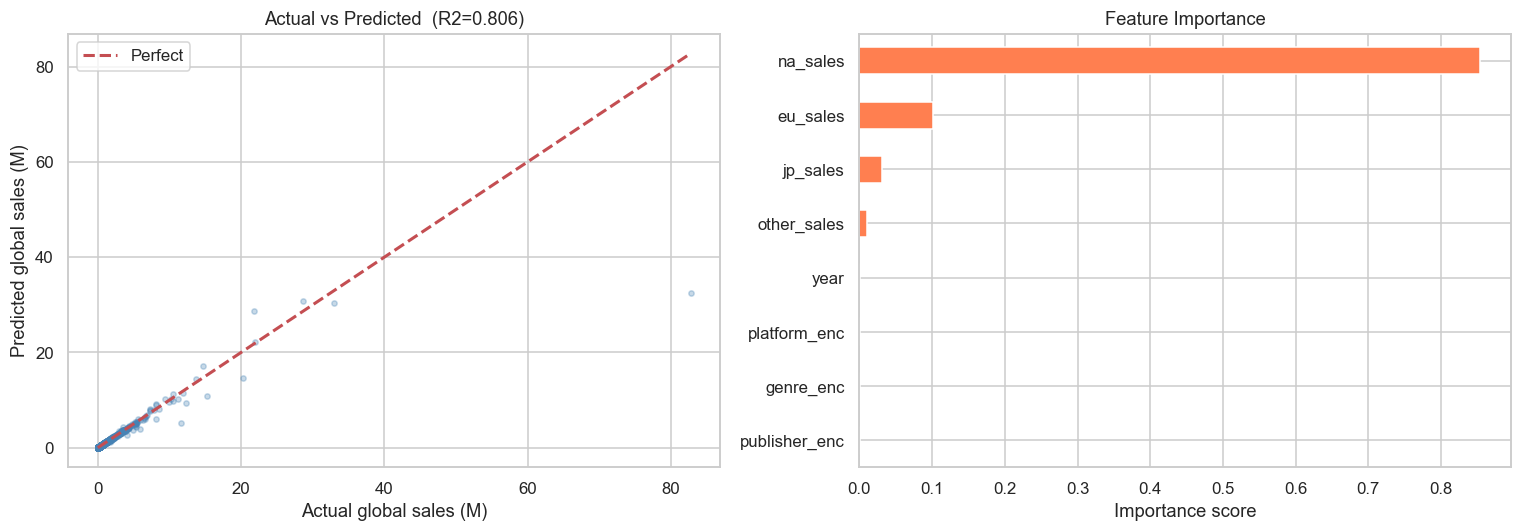


NA sales dominates — makes sense, it's the largest market.
EU and JP sales follow. Platform, genre, year contribute a little.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs actual
axes[0].scatter(y_test, y_pred, alpha=0.3, color='steelblue', s=12)
lim = max(y_test.max(), y_pred.max())
axes[0].plot([0, lim], [0, lim], 'r--', lw=2, label='Perfect')
axes[0].set_xlabel('Actual global sales (M)')
axes[0].set_ylabel('Predicted global sales (M)')
axes[0].set_title(f'Actual vs Predicted  (R2={r2:.3f})')
axes[0].legend()

# Feature importance
imp = pd.Series(rf.feature_importances_, index=features).sort_values()
imp.plot(kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Feature Importance')
axes[1].set_xlabel('Importance score')

plt.tight_layout()
plt.show()

print("\nNA sales dominates — makes sense, it's the largest market.")
print("EU and JP sales follow. Platform, genre, year contribute a little.")


## Takeaway

Random Forest handled the skewed sales data much better than a linear model would.
The model learned that NA sales is the strongest signal, which reflects reality —
a game that sells well in North America almost always sells well globally.

The hardest predictions are the outliers (games like Wii Sports or Mario Kart).
No model trained on typical games can fully predict a once-in-a-decade hit.
That's just an honest limitation of the data, not a flaw in the model.
